# Create the CSV and periodogram search

In [ ]:
# === Limpieza de saltos de telemetría: ahora en msv.cleaning ================
# sigma_clip_gap_edges     3σ global aplicado SOLO cerca de gaps/bordes
# clean_lightcurve         entry point de producción (sigma-clip en gaps/bordes)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from msv.cleaning import sigma_clip_gap_edges, clean_lightcurve


In [ ]:
# === DEV/TEST: sigma-clipping global aplicado solo cerca de gaps/bordes =====
# Lógica en msv.cleaning.sigma_clip_gap_edges: la mediana/std se calculan de
# la curva completa EXCLUYENDO las zonas vecinas (primeros/últimos bloques y
# los adyacentes a gaps > gap_thresh); el rechazo 3σ solo se aplica DENTRO
# de esas zonas.
SEG_DAYS, GAP_THRESH, SIGMA = 0.5, 1.0, 3.0

fig, axes = plt.subplots(len(FP_PAIRS), 1, figsize=(15, 4 * len(FP_PAIRS)))
if len(FP_PAIRS) == 1:
    axes = [axes]

for ax, (tic, sec) in zip(axes, FP_PAIRS):
    lc = pd.read_parquet(LC_PARQUET,
                         filters=[('TIC', '=', int(tic)), ('sector', '=', int(sec))],
                         columns=['Time', 'flux']).sort_values('Time')
    t = lc['Time'].to_numpy(); f = lc['flux'].to_numpy()
    m = np.isfinite(t) & np.isfinite(f); t, f = t[m], f[m]

    t, f, keep = sigma_clip_gap_edges(t, f, seg_days=SEG_DAYS, gap_thresh=GAP_THRESH,
                                      sigma=SIGMA, return_mask=True)
    drop = ~keep

    ax.plot(t[keep], f[keep], '.', ms=3, color='tab:blue', zorder=1)
    for g in np.where(np.diff(t) > GAP_THRESH)[0]:      # gaps reales sombreados
        ax.axvspan(t[g], t[g + 1], color='0.85', alpha=0.6, zorder=0)
    ax.plot(t[drop], f[drop], 'x', ms=7, color='black', mew=1.4, zorder=3,
            label=f'dropped (>{SIGMA:g} sigma global, en zona vecina, n={int(drop.sum())})')
    ax.set_title(f'TIC{tic} s{sec} | n={len(t)} pts')
    ax.set_xlabel('Time [BTJD]'); ax.set_ylabel('flux')
    ax.legend(fontsize=7, loc='best')

plt.tight_layout(); plt.show()


## Imports y funciones auxiliares

In [ ]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
from scipy.interpolate import UnivariateSpline
from scipy.signal import find_peaks, peak_prominences, peak_widths
from scipy import stats

# Pipeline msv (pip install -e . en el env base)
from msv import config as msv_config
from msv.cleaning import clean_lightcurve
from msv.periodograms import acf_periodogram, ls_periodogram
from msv.peaks import select_peaks_acf, select_peaks_ls


### acf_periodogram y periodogram

Las implementaciones viven en `msv.periodograms` (`ls_periodogram` con FAP de
Baluev; `acf_periodogram` statsmodels + Bartlett, opcionalmente con
`fill_gaps='noiselevel'` vía astrobase). Aquí solo queda un wrapper de
compatibilidad `periodogram(..., tipo="LS")`.


In [ ]:
# Wrapper de compatibilidad: las celdas antiguas llaman periodogram(tipo="LS").
def periodogram(time, flux, err, tipo="LS", plot=None, ax=None, **kw):
    if tipo != "LS":
        raise ValueError(f"tipo='{tipo}' no soportado")
    return ls_periodogram(time, flux, err, **kw)


### Detección de picos

`msv.peaks`: `find_peaks` sobre el power **crudo** (sin suavizado, resolución
de grilla intacta). El ACF usa una ventana temporal mínima entre picos
(`min_peak_sep_days` → `distance`) más una prominencia mínima
(`prominence_frac`), que reemplazan al suavizado gaussiano. El shim
`select_peaks` mantiene la firma antigua de este notebook.


In [ ]:
def select_peaks(per, power, fap=None, window=None, top_n=None, **kw):
    """Shim de compatibilidad -> msv.peaks.

    fap array  => ACF: select_peaks_acf (ventana temporal + prominencia,
                  cadencia derivada de la grilla uniforme en período).
    fap escalar => LS: select_peaks_ls (power - window > FAP si hay window;
                  freq_step derivado de la grilla uniforme en frecuencia).
    """
    per = np.asarray(per)
    fap_arr = np.asarray(fap) if fap is not None else None
    if fap_arr is not None and fap_arr.ndim > 0:
        cadence = float(np.median(np.diff(per)))
        return select_peaks_acf(per, power, fap_arr, cadence, top_n=top_n, **kw)
    freq_step = float(np.median(np.abs(np.diff(1.0 / per))))
    return select_peaks_ls(per, power, fap, window=window,
                           freq_step=freq_step, top_n=top_n, **kw)


## Carga del catálogo

In [ ]:
df_1 = pd.read_csv("catalogs/3_OGLEXTessV8_LC_DeltaMagnitude_Clean.csv").reset_index(drop=True)
df_aux = pd.read_csv("train_number_M.csv")
df_aux = df_aux.loc[df_aux["categorical_label"]!=7].reset_index(drop=True).drop_duplicates(subset=["ID","database"]).reset_index(drop=True)
df_1 = df_1.merge(df_aux[["ID","database","types","per"]],how="left",on=["ID","database"]).reset_index(drop=True)

# Marcar cortos
df_1.loc[df_1["per"]<13,"label"]=1
df_1.loc[df_1["label"].isna(),"label"]=0

print(f"Catálogo cargado: {len(df_1)} filas")
print(f"Etiqueta=1 (períodos cortos <13d): {(df_1['label']==1).sum()} filas")

## Validación de flujo (descartar curvas con flujo negativo)

Curvas con `flux <= 0` son un **error del cleaning** (p.ej. sobre-sustracción de fondo) y no deben procesarse: la amplitud `|−2.5·log10(fmax/fmin)|` queda indefinida. Se detectan a nivel `(TIC, sector)` y se excluyen de todo el pipeline (periodogramas y CNN) vía `BAD_FLUX_PAIRS`. Si un TIC tiene otros sectores limpios, esos sí se procesan.

In [ ]:
# === Validación: descartar curvas con flujo <= 0 (error de cleaning) ======
# El clasificador NO debe ver curvas con flujo negativo: la amplitud
# |−2.5·log10(fmax/fmin)| queda indefinida (NaN). Es un artefacto del cleaning
# (p.ej. sobre-sustracción de fondo). Se detecta a nivel (TIC, sector) y se
# excluye de TODO el procesamiento posterior (periodogramas + CNN) vía BAD_FLUX_PAIRS.
OUT_PARQUET = '/home/nicolas/nico/git/MassiveStarVariability/lightcurves_all_OGLE.parquet'

_flux_min = pd.read_parquet(OUT_PARQUET, columns=["TIC", "sector", "flux"]).groupby(
    ["TIC", "sector"])["flux"].min()
BAD_FLUX_PAIRS = {(int(t), int(s)) for (t, s) in _flux_min[_flux_min <= 0].index}

print(f"Pares (TIC, sector) con flujo <= 0 (excluidos): {len(BAD_FLUX_PAIRS)}")
for t, s in sorted(BAD_FLUX_PAIRS):
    print(f"  TIC {t}  sector {s}  (min flux = {_flux_min[(t, s)]:.2f})")

## Test: Una estrella

In [ ]:
OUT_PARQUET = '/home/nicolas/nico/git/MassiveStarVariability/lightcurves_all_OGLE.parquet'

def _parse_sector_list(s):
    """Parsea sector_list de string a lista."""
    if isinstance(s, (list, tuple, np.ndarray)):
        return list(s)
    try:
        return ast.literal_eval(s)
    except Exception:
        return []

# Elegir una estrella con período corto
sample_star = df_1.loc[df_1["label"]==1][["TIC","sector_list","per"]].sample(1, random_state=42)
TIC = int(sample_star.iloc[0]["TIC"])
sector_list = _parse_sector_list(sample_star.iloc[0]["sector_list"])
sector = int(sector_list[0]) if sector_list else None
per_true = float(sample_star.iloc[0]["per"])

if sector is None:
    raise ValueError(f"No sector found for TIC {TIC}")

print(f"Estrella: TIC {TIC}  sector {sector}  período verdadero: {per_true:.4f} d")

lc = pd.read_parquet(
    OUT_PARQUET,
    filters=[("TIC", "=", TIC), ("sector", "=", sector)],
    columns=["Time", "flux", "flux_err"],
)

print(f"Puntos de datos: {len(lc)}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.errorbar(lc["Time"], lc["flux"], yerr=lc["flux_err"],
            fmt='.', ms=2, elinewidth=0.3, color='k', alpha=0.6)
ax.set_xlabel("Time [BTJD]")
ax.set_ylabel("PDCSAP flux [e-/s]")
ax.set_title(f"TIC {TIC} — sector {sector} (período verdadero: {per_true:.4f} d)")
plt.tight_layout()
plt.show()

## Correr LS y ACF en la estrella

In [ ]:
t = lc["Time"].values
f = lc["flux"].values
e = lc["flux_err"].values

cad = float(np.median(np.diff(t)))
baseline = t.max() - t.min()

print(f"Cadencia (median diff): {cad:.6f} d ({cad*1440:.2f} min)")
print(f"Baseline               : {baseline:.3f} d")
print(f"per_min (2*cadence)    : {2*cad:.6f} d")
print(f"per_max (baseline/2)   : {baseline/2:.3f} d")
print(f"Rayleigh df (1/base)   : {1/baseline:.5f} cycles/day")

# LS y ACF
df_ls = periodogram(t, f, e, tipo="LS", oversample=5)
df_acf = acf_periodogram(t, f, e)

# LS window
freq_ls = 1.0 / df_ls["per"].values
ones = np.ones_like(t)
df_ls["window"] = LombScargle(
    t, ones, center_data=False, fit_mean=False, normalization="standard"
).power(freq_ls)

print("\n--- LS ---")
print(f"  filas={len(df_ls)}  step={df_ls.attrs['step_cpd']:.5f} cpd  "
      f"oversample={df_ls.attrs['oversample']}")
print(f"  FAP({df_ls.attrs['fap_method']}, alpha={df_ls.attrs['fap_alpha']})="
      f"{df_ls.attrs['fap_level']:.4f}")
print("  Top 5 picos por potencia:")
print(df_ls.sort_values("power", ascending=False).head(5)[["per", "power"]].to_string(index=False))

print("\n--- ACF ---")
print(f"  filas={len(df_acf)}  N_eff={df_acf.attrs['n_eff']}  "
      f"n_search={df_acf.attrs['n_search']}")
print(f"  FAP({df_acf.attrs['fap_method']}, alpha={df_acf.attrs['fap_alpha']}): "
      f"min={df_acf['fap'].min():.4f}  max={df_acf['fap'].max():.4f}")
print("  Top 5 picos (power > FAP):")
sig = df_acf[df_acf["power"] > df_acf["fap"]].sort_values("power", ascending=False).head(5)
print(sig[["per", "power", "fap"]].to_string(index=False))

## Detectar picos (LS y ACF sobre power crudo, sin suavizado)


In [ ]:
# LS: detectar con power - window > FAP
fap_ls = df_ls.attrs["fap_level"]
peaks_ls = select_peaks_ls(
    df_ls["per"].values, df_ls["power"].values, fap_ls,
    window=df_ls["window"].values, freq_step=df_ls.attrs["step_cpd"],
)

# ACF: ventana temporal + prominencia, power > FAP (Bartlett confint)
peaks_acf = select_peaks_acf(
    df_acf["per"].values, df_acf["power"].values, df_acf["fap"].values,
    df_acf.attrs["cadence_days"],
)

print("=== Picos detectados ===")
print(f"\nLS ({len(peaks_ls)} picos, criterio: power - window > FAP):")
if not peaks_ls.empty:
    print(peaks_ls.to_string(index=False))
else:
    print("  ninguno")

print(f"\nACF ({len(peaks_acf)} picos, criterio: power > FAP + ventana + prominencia):")
if not peaks_acf.empty:
    print(peaks_acf.to_string(index=False))
else:
    print("  ninguno")


## Gráficos: LS y ACF con picos detectados

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# LS panel
ax = axes[0]
ax.plot(df_ls["per"], df_ls["window"], color="0.6", lw=0.6, label="window (LS of flux=1)")
ax.plot(df_ls["per"], df_ls["power"], "k-", lw=0.7, label="LS power")
power_corrected_ls = df_ls["power"] - df_ls["window"]
ax.plot(df_ls["per"], power_corrected_ls, "c-", lw=0.7, alpha=0.6, label="power - window (criterio de detección)")
ax.axhline(fap_ls, color="r", ls="--", lw=1.0, label=f"FAP = {fap_ls:.3f}")
if not peaks_ls.empty:
    ax.plot(peaks_ls["per"], peaks_ls["power"], "o", color="tab:orange",
            ms=7, mfc="none", mew=1.5, label=f"{len(peaks_ls)} picos detectados")
    for _, r in peaks_ls.iterrows():
        ax.annotate(f"{r['per']:.4f} d", (r["per"], r["power"]),
                    xytext=(4, 4), textcoords="offset points", fontsize=9)
ax.axvline(per_true, color="green", ls=":", lw=1.5, alpha=0.7, label=f"período verdadero: {per_true:.4f} d")
ax.set_xscale("log")
ax.set_ylabel("LS power", fontsize=12)
ax.set_title(f"Lomb-Scargle — TIC {TIC} sector {sector} (criterio: power - window > FAP)", fontsize=13)
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3, which="both")

# ACF panel
ax = axes[1]
ax.plot(df_acf["per"], df_acf["power"], "k-", lw=0.7, label="ACF")
ax.fill_between(df_acf["per"], -df_acf["fap"], df_acf["fap"], alpha=0.2, color="red", label="FAP ±Bartlett")
if not peaks_acf.empty:
    ax.plot(peaks_acf["per"], peaks_acf["power"], "o", color="tab:orange",
            ms=7, mfc="none", mew=1.5, label=f"{len(peaks_acf)} picos detectados (power > FAP)")
    for _, r in peaks_acf.iterrows():
        ax.annotate(f"{r['per']:.4f} d", (r["per"], r["power"]),
                    xytext=(4, 4), textcoords="offset points", fontsize=9)
ax.axvline(per_true, color="green", ls=":", lw=1.5, alpha=0.7, label=f"período verdadero: {per_true:.4f} d")
ax.axhline(0, color="0.85", lw=0.5)
ax.set_xscale("log")
ax.set_xlabel("Period / Lag [d]", fontsize=12)
ax.set_ylabel("ACF", fontsize=12)
ax.set_title("ACF (criterio: power > FAP Bartlett-statsmodels)", fontsize=13)
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

## Revisión del ACF: ventana temporal + prominencia (sin suavizado)

El suavizado gaussiano (σ=50 pts ≈ 0.12 d a cadencia de 200 s) perdía
resolución de la grilla de períodos: en 68 pares label=1 recuperaba **0%**
de los `per_ogle`. El reemplazo — `find_peaks` sobre el ACF crudo con
`distance = min_peak_sep_days/cadencia` y `prominence_frac` — recupera ~76%
y elimina los picos espurios de los 24 FP conocidos.


In [ ]:
# === Revisión ACF: ventana temporal + prominencia (una estrella) ============
# find_peaks corre sobre el ACF CRUDO: distance = min_peak_sep_days/cadencia
# suprime picos vecinos y prominence_frac elimina los wiggles de ruido sobre
# el decaimiento de red noise (lo que antes hacía el suavizado gaussiano).
TIC_REVIEW    = 45589186
SECTOR_REVIEW = 66
MIN_SEP_DAYS  = msv_config.MIN_PEAK_SEP_DAYS      # 0.5 d
PROM_FRAC     = msv_config.ACF_PROMINENCE_FRAC    # 0.05

lc_r = pd.read_parquet(
    OUT_PARQUET,
    filters=[("TIC", "=", TIC_REVIEW), ("sector", "=", SECTOR_REVIEW)],
    columns=["Time", "flux", "flux_err"],
)
t_r, f_r, e_r = lc_r["Time"].values, lc_r["flux"].values, lc_r["flux_err"].values

df_acf_r = acf_periodogram(t_r, f_r, e_r)
per   = df_acf_r["per"].values
power = df_acf_r["power"].values
cad_r = df_acf_r.attrs["cadence_days"]

peaks_r = select_peaks_acf(per, power, df_acf_r["fap"].values, cad_r,
                           min_peak_sep_days=MIN_SEP_DAYS,
                           prominence_frac=PROM_FRAC)

print(f"TIC {TIC_REVIEW} sector {SECTOR_REVIEW}  min_sep={MIN_SEP_DAYS} d "
      f"(distance={max(1, int(round(MIN_SEP_DAYS / cad_r)))} muestras)  "
      f"prom_frac={PROM_FRAC}  N_acf={len(power)}")
print(f"  picos detectados: {len(peaks_r)}")
if not peaks_r.empty:
    print(peaks_r[["per", "power", "prominence"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(per, power, color="k", lw=0.7, label="ACF crudo")
ax.fill_between(per, -df_acf_r["fap"], df_acf_r["fap"], alpha=0.2, color="red",
                label="FAP ±Bartlett")
if not peaks_r.empty:
    ax.plot(peaks_r["per"], peaks_r["power"], "o", color="tab:orange",
            ms=8, mfc="none", mew=1.5, label=f"{len(peaks_r)} picos")
    for _, r in peaks_r.iterrows():
        ax.annotate(f"{r['per']:.4f} d", (r["per"], r["power"]),
                    xytext=(4, 4), textcoords="offset points", fontsize=9)
ax.axhline(0, color="0.85", lw=0.5)
ax.set_xscale("log")
ax.set_xlabel("Period / Lag [d]", fontsize=12)
ax.set_ylabel("ACF", fontsize=12)
ax.set_title(f"ACF crudo + ventana temporal — TIC {TIC_REVIEW} sector {SECTOR_REVIEW}", fontsize=13)
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()


## Procesar todo el sample y guardar picos

El batch vive en `scripts/run_peaks.py` (env base): incluye
`clean_lightcurve` (sigma-clip en gaps/bordes), exclusión automática de pares con
`flux <= 0`, ACF sin suavizado (ventana temporal + prominencia) y hist2d +
amplitude por peak.


In [ ]:
# === Batch LS+ACF: scripts/run_peaks.py =====================================
OUT_PARQUET = '/home/nicolas/nico/git/MassiveStarVariability/lightcurves_all_OGLE.parquet'
PEAKS_OUT = '/home/nicolas/nico/git/MassiveStarVariability/peaks_statsmodels.parquet'

!python scripts/run_peaks.py --lc {OUT_PARQUET} --out {PEAKS_OUT} --min-peak-sep-days 0.5


## Clasificación CNN + BRF sobre los picos OGLE

Pasa cada pico de `peaks_statsmodels.parquet` por el clasificador **CNN + BRF**
de `Paper_OGLE` (análogo a `3_HowToUse_CNN_BRF.ipynb`, que es el ejemplo TESS):

1. **hist2d**: como el parquet de picos OGLE solo trae `per/power/...` (sin
   imágenes), se reconstruye el histograma 2D phase-folded (32×32, log1p) de
   cada pico desde la curva OGLE (`lightcurves_all_OGLE.parquet`), con la
   **misma** función que el pipeline TESS.
2. **amplitud**: `|−2.5·log10(fmax/fmin)|` por estrella (NaN si flujo ≤ 0).
3. **CNN** → 8 probabilidades de clase `['ELL','M','CEP','DST','E','LPV','RR','Rndm']`.
4. **BRF** → clase final a partir de las 8 probs CNN + `amplitud` + `per`.

**Salida:** `OGLE_CNN_BRF_predictions.csv` (una fila por pico).

> ⚠️ **Entorno (kernel):** usar **`CNN_TESS_min`** (sklearn 1.0.2 + tf 2.13.1).
> El `balanced_random_forest_model.joblib` fue serializado con sklearn < 1.3,
> así que falla al cargar con sklearn ≥ 1.3 (p.ej. `CNN_TESS`, que tiene 1.3.0)
> por incompatibilidad del dtype de los nodos del árbol.

In [ ]:
# --- 1) Cargar CNN (pesos Paper_OGLE) + BRF -------------------------------
# Esta seccion es autocontenida: lee los parquets ya generados arriba y se
# ejecuta en el kernel CNN_TESS_min (no depende de statsmodels/astropy).
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf

PEAKS_OGLE  = "/home/nicolas/nico/git/MassiveStarVariability/peaks_statsmodels.parquet"
LC_OGLE     = "/home/nicolas/nico/git/MassiveStarVariability/lightcurves_all_OGLE.parquet"
CNN_WEIGHTS = "/home/nicolas/nico/git/Paper_OGLE/Weights/batchBalanced_Number_M/cp.ckpt"
BRF_PATH    = "/home/nicolas/nico/git/balanced_random_forest_model.joblib"
OUT_CSV     = "/home/nicolas/nico/git/MassiveStarVariability/OGLE_CNN_BRF_predictions.csv"

CLASS_NAMES = ['ELL', 'M', 'CEP', 'DST', 'E', 'LPV', 'RR', 'Rndm']
print("TF:", tf.__version__)

# Misma arquitectura que CNN_2dhist_function.make_model() de Paper_OGLE.
def make_model():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(16, (3, 3), input_shape=(32, 32, 1), activation="relu", padding="same"),
        tf.keras.layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1024, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(512, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(8, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.9, beta_2=0.999, epsilon=0.1),
        loss="sparse_categorical_crossentropy",
        metrics=["acc"],
    )
    return model

model_softmax = make_model()
model_softmax.load_weights(CNN_WEIGHTS)
print("CNN pesos cargados:", CNN_WEIGHTS)

brf = joblib.load(BRF_PATH)
print("BRF features:", list(brf.feature_names_in_))

In [ ]:
# --- 2) hist2d phase-folded + amplitud ------------------------------------
# Identico a `_phase_fold_hist2d_log` y al calculo de amplitud del pipeline
# TESS (notebook 2_Github_TESS_variability_MassiveStarG12). La CNN fue
# entrenada con estos histogramas 32x32 normalizados en log1p.
N_EDGES = 33

def phase_fold_hist2d_log(time, flux, period, n_edges=N_EDGES):
    """Phase-fold + histograma 2D (fase x flujo) con normalizacion log1p."""
    fase = np.mod(time, period) / period
    bins_x = np.linspace(0.0, 1.0, n_edges)
    bins_y = np.linspace(flux.min(), flux.max(), n_edges)
    h, _, _ = np.histogram2d(fase, flux, bins=(bins_x, bins_y))
    hmax = h.max()
    if hmax > 0:
        h = np.log1p(h) / np.log1p(hmax)
    h = h.T[::-1]
    return h.astype(np.float32)

def amplitude_of(f):
    """Amplitud en magnitudes: |−2.5 log10(fmax/fmin)|. NaN si hay flujo <= 0."""
    if f.min() > 0:
        return float(np.absolute(-2.5 * np.log10(f.max() / f.min())))
    return float("nan")

In [ ]:
# --- 3) Construir hist2d (32x32) + amplitud por pico ----------------------
# peaks_statsmodels.parquet NO trae hist2d ni amplitude: se generan aqui
# phase-folding la curva OGLE en el periodo de cada pico.
peaks_ogle = pd.read_parquet(PEAKS_OGLE).reset_index(drop=True)
print(f"Picos OGLE: {len(peaks_ogle)}  | TICs: {peaks_ogle['TIC'].nunique()}")

lc_all = pd.read_parquet(LC_OGLE, columns=["Time", "flux", "TIC", "sector"])
lc_groups = {k: v for k, v in lc_all.groupby(["TIC", "sector"], sort=False)}

N = len(peaks_ogle)
X = np.zeros((N, 32, 32, 1), dtype=np.float32)
amp = np.full(N, np.nan, dtype=np.float64)
amp_cache = {}   # amplitud no depende del periodo: cachear por (TIC, sector)
n_skip = 0

for i, row in enumerate(peaks_ogle.itertuples(index=False)):
    key = (row.TIC, row.sector)
    lc = lc_groups.get(key)
    if lc is None:
        n_skip += 1
        continue
    t = lc["Time"].to_numpy()
    f = lc["flux"].to_numpy()
    m = np.isfinite(t) & np.isfinite(f)
    t, f = t[m], f[m]
    if len(t) < 20:
        n_skip += 1
        continue
    if key not in amp_cache:
        amp_cache[key] = amplitude_of(f)
    amp[i] = amp_cache[key]
    X[i, ..., 0] = phase_fold_hist2d_log(t, f, float(row.per))

print(f"Cubo de hist2d: {X.shape}  | picos sin curva válida: {n_skip}")

In [ ]:
# --- 4) CNN predict + BRF predict + guardar -------------------------------
# CNN: 8 probabilidades de clase por pico.
probs_all = model_softmax.predict(X, batch_size=512, verbose=1)
df_probs = pd.DataFrame(probs_all, columns=CLASS_NAMES)

# BRF: espera 8 probs CNN + 'amplitud' + 'per' (en el orden de feature_names_in_).
df_brf = df_probs.copy()
df_brf["amplitud"] = amp
df_brf["per"] = peaks_ogle["per"].to_numpy()
df_brf = df_brf[list(brf.feature_names_in_)]

# Filtrar NaN (estrellas con flujo negativo -> amplitud NaN) antes de predecir.
mask_ok = df_brf.notna().all(axis=1).to_numpy()
brf_pred = np.full(N, -1, dtype=int)
brf_proba = np.full((N, 8), np.nan, dtype=float)
brf_pred[mask_ok] = brf.predict(df_brf.loc[mask_ok])
brf_proba[mask_ok] = brf.predict_proba(df_brf.loc[mask_ok])

# Tabla final: pico + amplitud + probs CNN + clase/prob BRF.
out = peaks_ogle[["TIC", "sector", "source", "per", "power", "prominence", "width"]].copy()
out["amplitude"] = amp
for j, c in enumerate(CLASS_NAMES):
    out[f"cnn_{c}"] = probs_all[:, j]
out["brf_class"] = [CLASS_NAMES[c] if c >= 0 else None for c in brf_pred]
out["brf_prob"] = [brf_proba[i, brf_pred[i]] if brf_pred[i] >= 0 else np.nan
                   for i in range(N)]

out.to_csv(OUT_CSV, index=False)
print("\n=== Distribución de clases BRF (OGLE) ===")
print(out["brf_class"].value_counts(dropna=False).to_string())
print(f"\n-> {OUT_CSV}  ({len(out)} filas)")
out.head()

## Path 2 — Catálogo por cascada jerárquica (selección por peaks)

Ruta alternativa de clasificación ("path 2") para testear la robustez de la distribución de clases frente al criterio de selección. **Paralela** al criterio por pico de arriba; no lo reemplaza. Decide una **clase única por TIC** (`final_class_tic`) mediante una cascada:

1. **Paso 1 — no periódicos (nivel TIC):** reglas jerárquicas, la primera que matchea gana y el TIC sale del pipeline.
   - `No_periodo`: el TIC no tiene ningún peak (ni LS ni ACF).
   - `Rndm`: **todos** los peaks son `Rndm` y al menos uno tiene `brf_prob ≥ threshold`.
   - `Irregular`: todos los peaks ∈ `{Rndm, LPV}`, al menos uno `LPV`, y al menos uno `≥ threshold`.
2. **Paso 2 — periódicos (voto por sector):** para el resto. Pre-filtra a peaks de clase periódica y vota por sector (ACF vs LS, desempates por `power`); la **moda** de los votos define la clase. Sectores sin peak sobre `threshold` quedan `Unconstrained` (0 votos); empate en la moda → `Mixed`; todos los sectores `Unconstrained` → `Unconstrained`.

**Adaptación al notebook OGLE.** El spec original (pipeline TESS) usaba dos CSVs (`CNN_RF_prediction_{LS,ACF}_log.csv`) con columnas `final_class` / `CNN+RF_max_prob`. Aquí se usa el **único** `OGLE_CNN_BRF_predictions.csv` (LS y ACF combinados vía columna `source`), con el mapeo: `final_class→brf_class`, `CNN+RF_max_prob→brf_prob`, `period→per`, `sector_list→sector`. Clases periódicas OGLE: `{ELL, M, CEP, DST, E, RR}`; no periódicas: `{Rndm, LPV}`. Los peaks con `brf_class` nulo (flujo ≤ 0 → amplitud `NaN`) se descartan al cargar.

**Parámetros:** `threshold = 0.8` (sobre `brf_prob`), `rng = np.random.default_rng(seed=42)` (solo desempates en sectores `Unconstrained`, por consistencia con path 1).

**Salidas** en `catalogs/`: `catalog_path2_main.csv` (peaks ganadores por sector + peaks top de sectores `Unconstrained`, con `final_class_tic`, `sector_class`, `decision_step` y columnas originales `per/power/source/cube_idx/...`), `catalog_path2_mixed.csv`, y un `catalog_path2_{clase}.csv` por cada `final_class_tic` (excluyendo `Mixed`).

> ⚠️ **Kernel:** `CNN_TESS_min`. La sección es autocontenida (solo lee el CSV de predicciones + el catálogo). **No** se compara con path 1 aquí (ese análisis es posterior, fuera de alcance).

In [ ]:
# === Path 2 · Paso 0: carga, parametros y universo de TICs ================
# Autocontenida: lee OGLE_CNN_BRF_predictions.csv (un solo CSV LS+ACF combinado
# via columna `source`). Kernel: CNN_TESS_min.
import os
import numpy as np
import pandas as pd

BASE     = "/home/nicolas/nico/git/MassiveStarVariability"
PRED_CSV = os.path.join(BASE, "OGLE_CNN_BRF_predictions.csv")
CATALOG  = os.path.join(BASE, "catalogs/3_OGLEXTessV8_LC_DeltaMagnitude_Clean.csv")
OUT_DIR  = os.path.join(BASE, "catalogs")

threshold = 0.8                          # umbral sobre brf_prob (= CNN+RF_max_prob)
rng = np.random.default_rng(seed=42)     # solo desempates en sectores Unconstrained

# Mapeo de columnas spec(TESS) -> notebook OGLE
CLASS_COL, PROB_COL = "brf_class", "brf_prob"      # final_class, CNN+RF_max_prob
PER_COL, POWER_COL, SECTOR_COL = "per", "power", "sector"
NONPER   = {"Rndm", "LPV"}                          # no periodicas (No_periodo = sin peaks)
PERIODIC = {"ELL", "M", "CEP", "DST", "E", "RR"}    # periodicas (voto por sector)

df_p2 = pd.read_csv(PRED_CSV)
df_p2["cube_idx"] = np.arange(len(df_p2))           # posicion en el cubo CNN (orden original)
n_nan = int(df_p2[CLASS_COL].isna().sum())
df_p2 = df_p2[df_p2[CLASS_COL].notna()].reset_index(drop=True)  # descartar peaks no clasificables (flujo<=0)

cat_tics  = set(pd.read_csv(CATALOG)["TIC"].astype(int).unique())
peak_tics = set(df_p2["TIC"].astype(int).unique())
no_periodo_tics = sorted(cat_tics - peak_tics)      # TICs del catalogo sin ningun peak

print(f"Peaks: {len(df_p2)} (descartados {n_nan} sin clase) | TICs con peaks: {len(peak_tics)}")
print(f"threshold={threshold} | No_periodo (TICs sin peaks)={len(no_periodo_tics)}")

In [ ]:
# === Path 2 · Paso 1: candidatos NO periodicos (granularidad TIC) =========
# Reglas jerarquicas: la primera que matchea gana y el TIC sale del pipeline.
def classify_tic_step1(g):
    classes  = set(g[CLASS_COL])
    has_over = bool((g[PROB_COL] >= threshold).any())
    if classes == {"Rndm"} and has_over:                              # 1.2 Rndm
        return "Rndm"
    if classes <= {"Rndm", "LPV"} and "LPV" in classes and has_over:  # 1.3 Irregular
        return "Irregular"
    return None                                                       # 1.4 -> Paso 2

# 1.1 No_periodo (TICs sin ningun peak) ya esta en `no_periodo_tics`; se ensambla en Paso 3.
step1, fallthrough = {}, []
for tic, g in df_p2.groupby("TIC"):
    lab = classify_tic_step1(g)
    if lab is None:
        fallthrough.append(tic)
    else:
        step1[tic] = lab

print(f"Paso 1 -> Rndm={sum(v == 'Rndm' for v in step1.values())} "
      f"Irregular={sum(v == 'Irregular' for v in step1.values())} "
      f"| fall-through (-> Paso 2)={len(fallthrough)}")

In [ ]:
# === Path 2 · Paso 2: candidatos PERIODICOS (voto por sector) =============
# Solo TICs que cayeron a fall-through. Pre-filtro: solo peaks de clase periodica.
def _acf_winner(sub):   # desempate: mayor power
    return sub.sort_values([PROB_COL, POWER_COL], ascending=[False, False]).iloc[0]
def _ls_winner(sub):    # desempate: menor power
    return sub.sort_values([PROB_COL, POWER_COL], ascending=[False, True]).iloc[0]

out_rows, step2 = [], {}
for tic in fallthrough:
    g = df_p2[(df_p2["TIC"] == tic) & (df_p2[CLASS_COL].isin(PERIODIC))]   # pre-filtro
    votes, tic_rows, sector_flags = [], [], []
    for sector, sg in g.groupby(SECTOR_COL):
        acf = sg[sg["source"] == "ACF"]
        ls  = sg[sg["source"] == "LS"]
        a = _acf_winner(acf) if len(acf) else None
        l = _ls_winner(ls)   if len(ls)  else None
        if not bool((sg[PROB_COL] >= threshold).any()):       # Caso A: Unconstrained (0 votos)
            sector_flags.append("Unconstrained")
            if a is not None and l is not None and a[PROB_COL] == l[PROB_COL]:
                keep = [a] if rng.choice(["ACF", "LS"]) == "ACF" else [l]   # desempate aleatorio
            else:
                keep = [r for r in (a, l) if r is not None]
            for r in keep:
                r = r.copy(); r["sector_class"] = "Unconstrained"; tic_rows.append(r)
        else:                                                 # Caso B: aporta voto(s)
            sector_flags.append("voted")
            if a is not None and l is not None:
                if   a[PROB_COL] > l[PROB_COL]: win = [a]
                elif l[PROB_COL] > a[PROB_COL]: win = [l]
                else:                           win = [a, l]  # empate ACF=LS -> 2 votos
            else:
                win = [r for r in (a, l) if r is not None]
            for r in win:
                votes.append(r[CLASS_COL])
                r = r.copy(); r["sector_class"] = r[CLASS_COL]; tic_rows.append(r)

    if len(votes) == 0:                       # todos Unconstrained o sin peaks periodicos
        final = "Unconstrained"
    else:
        vc = pd.Series(votes).value_counts()
        modes = vc[vc == vc.max()].index.tolist()
        final = modes[0] if len(modes) == 1 else "Mixed"     # empate en la moda -> Mixed
    step2[tic] = final
    if not tic_rows:                          # garantizar que el TIC aparezca en main
        r = pd.Series({c: np.nan for c in df_p2.columns}); r["TIC"] = tic
        r["sector_class"] = "Unconstrained"; tic_rows = [r]
    for r in tic_rows:
        r = r.copy(); r["final_class_tic"] = final; r["decision_step"] = 2
        out_rows.append(r)

print(f"Paso 2 -> {len(step2)} TICs | Mixed={sum(v == 'Mixed' for v in step2.values())} "
      f"Unconstrained={sum(v == 'Unconstrained' for v in step2.values())}")

In [ ]:
# === Path 2 · Paso 3: ensamblar catalogo + escribir CSVs ==================
# Filas de Paso 1 (todos los peaks del TIC) y No_periodo (fila minima por TIC).
for tic, lab in step1.items():
    for _, r in df_p2[df_p2["TIC"] == tic].iterrows():
        r = r.copy(); r["final_class_tic"] = lab; r["sector_class"] = lab; r["decision_step"] = 1
        out_rows.append(r)
for tic in no_periodo_tics:
    r = pd.Series({c: np.nan for c in df_p2.columns})
    r["TIC"] = tic; r["final_class_tic"] = "No_periodo"; r["sector_class"] = "No_periodo"; r["decision_step"] = 1
    out_rows.append(r)

main = pd.DataFrame(out_rows).reset_index(drop=True)
main["TIC"] = main["TIC"].astype(int)
tic_class = {**step1, **step2, **{t: "No_periodo" for t in no_periodo_tics}}

os.makedirs(OUT_DIR, exist_ok=True)
main.to_csv(os.path.join(OUT_DIR, "catalog_path2_main.csv"), index=False)
main[main["final_class_tic"] == "Mixed"].to_csv(
    os.path.join(OUT_DIR, "catalog_path2_mixed.csv"), index=False)
for clase, sub in main.groupby("final_class_tic"):   # un CSV por clase (excluye Mixed)
    if clase == "Mixed":
        continue
    sub.to_csv(os.path.join(OUT_DIR, f"catalog_path2_{clase}.csv"), index=False)

# --- Resumen en consola ---------------------------------------------------
print("=== Path 2 · resumen ===")
print(f"TICs: {main['TIC'].nunique()} | filas en catalog_path2_main: {len(main)}")
print("\nfinal_class_tic (por TIC):")
print(pd.Series(tic_class).value_counts().to_string())
print(f"\nMixed TICs:         {sum(v == 'Mixed' for v in tic_class.values())}")
print(f"Unconstrained TICs: {sum(v == 'Unconstrained' for v in tic_class.values())}")
print(f"\n-> {OUT_DIR}/catalog_path2_*.csv")

## Clase 0 — dispersión MC del BRF (media vs σ)

Aislamos el problema: **solo** los TICs benchmark con `label=0` (no deberían ser periódicos).
Por cada pico hacemos `N_MC` pasadas con `Dropout(0.3)` activo (`training=True`): cada pasada da 8
probs CNN distintas que entran al BRF y devuelven un *hot-vector* de 8 `predict_proba`.
Sobre las N pasadas calculamos **media** y **σ** del hot-vector.

Scatter: eje **X** = media más alta del hot-vector, eje **Y** = σ de esa misma clase, **color** = clase (argmax de la media).
Reusa de celdas previas: `X`, `amp`, `peaks_ogle`, `model_softmax`, `brf`, `CLASS_NAMES`, `df_1`.

### Agrupar clases pulsantes regulares en una sola "Puls"

Para massive stars (que no son RRL ni DST) la confusión *entre* pulsantes da igual: juntamos
`M, CEP, DST, RR` → **Puls** sumando sus probabilidades **antes** de media/σ/argmax. **LPV no entra**
(según OGLE puede ser irregular, no pulsante regular) y queda como grupo propio. Grupos:
`Puls, LPV, ELL, E, Rndm`; **FP = todo lo que no sea Rndm ni LPV** (Puls, ELL o E). Todas
las celdas siguientes usan `group_meansigma`, `GROUP_NAMES` y `NON_FP` de aquí.

In [132]:
# === Agrupar clases pulsantes regulares en una sola "Puls" ===============
# LPV NO entra: segun OGLE puede ser irregular -> queda como grupo propio.
PULS        = ["M", "CEP", "DST", "RR"]
CLASS2GROUP = {c: ("Puls" if c in PULS else c) for c in CLASS_NAMES}
GROUP_NAMES = ["Puls", "LPV", "ELL", "E", "Rndm"]
GMAT   = np.array([[1.0 if CLASS2GROUP[c] == g else 0.0 for c in CLASS_NAMES]
                   for g in GROUP_NAMES])              # (5,8): suma de probs por grupo
NON_FP = {"LPV", "Rndm"}                                # => FP = todo lo demas (Puls/ELL/E)
SIGMA_MAX, PROB_MIN = 0.12, 0.90                       # corte fijo del gate

def group_meansigma(proba8_mc):
    """(N,P,8) probs del BRF -> (prob_max, sigma_de_esa_clase, clase) en GROUP_NAMES,
    sumando las probs pulsantes (M/CEP/DST/RR) ANTES de media/sigma/argmax."""
    g = proba8_mc @ GMAT.T                              # (N,P,5)
    mean = g.mean(0); sigma = g.std(0); cls = mean.argmax(1); P = g.shape[1]
    return mean[np.arange(P), cls], sigma[np.arange(P), cls], np.array(GROUP_NAMES)[cls]

print("grupos:", GROUP_NAMES, "| Puls:", PULS, "| FP=NOT(Rndm,LPV) | corte: sig<%.2f & prob>%.2f" % (SIGMA_MAX, PROB_MIN))

grupos: ['Puls', 'LPV', 'ELL', 'E', 'Rndm'] | Puls: ['M', 'CEP', 'DST', 'RR'] | FP=NOT(Rndm,LPV) | corte: sig<0.12 & prob>0.90


TICs label=0: 113 | picos clase 0 con curva valida: 7957
  batchBalanced_Number_DST: 10.9s
  batchBalanced_Number_ELL: 11.2s
  batchBalanced_Number_M: 12.2s
  Number_CEP: 12.4s
  Number_DST: 12.8s
  Number_ELL: 12.7s
  Number_M: 12.3s


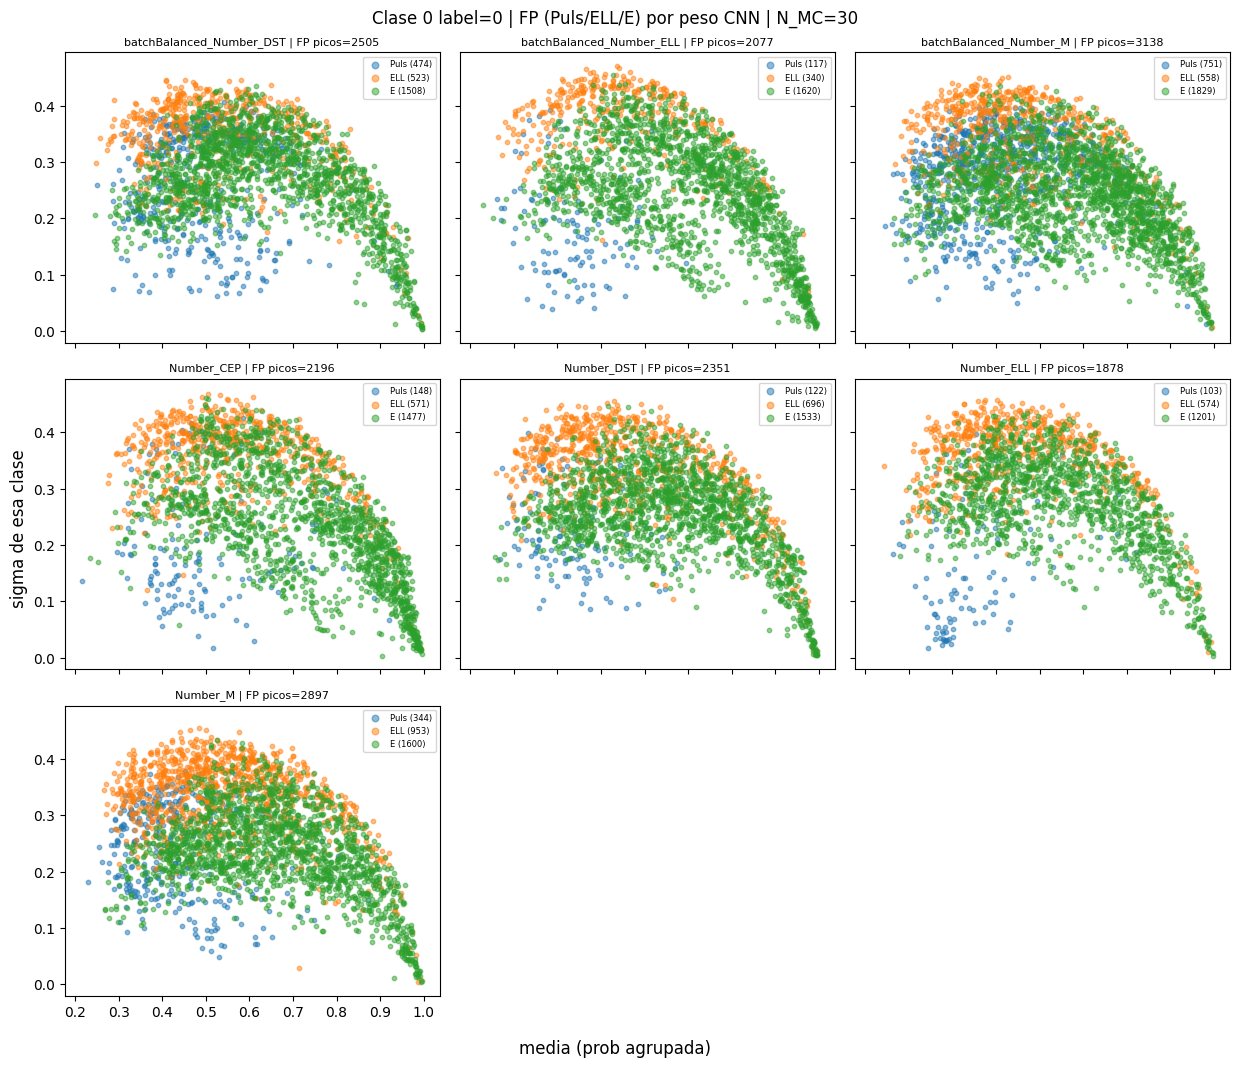

In [133]:
# === Clase 0: FP en prob-sigma, un subplot por cada peso CNN =============
import matplotlib.pyplot as plt, time
N_MC = 30
WEIGHTS_DIR = "/home/nicolas/nico/git/Paper_OGLE/Weights"
MODELS = ["batchBalanced_Number_DST", "batchBalanced_Number_ELL", "batchBalanced_Number_M",
          "Number_CEP", "Number_DST", "Number_ELL", "Number_M"]

labels = df_1.drop_duplicates("TIC").set_index("TIC")["label"].astype(int)
tic0 = set(labels[labels == 0].index)
mask = peaks_ogle["TIC"].isin(tic0).to_numpy() & np.isfinite(amp)
idx  = np.where(mask)[0]
X0 = X[idx]; per0 = peaks_ogle["per"].to_numpy()[idx]; amp0 = amp[idx]; P0 = len(idx)
feat_order = list(brf.feature_names_in_)
print(f"TICs label=0: {len(tic0)} | picos clase 0 con curva valida: {P0}")

FP_GROUPS = [g for g in GROUP_NAMES if g not in NON_FP]          # Puls, ELL, E (no Rndm/LPV)
COLORS = dict(zip(FP_GROUPS, plt.cm.tab10.colors))

ncols = 3; nrows = int(np.ceil(len(MODELS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.6 * nrows),
                         squeeze=False, sharex=True, sharey=True)
for ax in axes.ravel():
    ax.axis("off")

cls0_by_model = {}
for k, name in enumerate(MODELS):
    t0 = time.time()
    tf.keras.backend.clear_session(); m = make_model(); m.load_weights(f"{WEIGHTS_DIR}/{name}/cp.ckpt")
    probs_mc = np.stack([m(X0, training=True).numpy() for _ in range(N_MC)])
    feat = pd.DataFrame(probs_mc.reshape(N_MC * P0, 8), columns=CLASS_NAMES)
    feat["per"] = np.tile(per0, N_MC); feat["amplitud"] = np.tile(amp0, N_MC)
    hot = brf.predict_proba(feat[feat_order]).reshape(N_MC, P0, 8)
    xi, yi, cli = group_meansigma(hot)
    cls0_by_model[name] = (xi, yi, cli)
    ax = axes[k // ncols][k % ncols]; ax.axis("on")
    nfp = 0
    for c in FP_GROUPS:
        s = cli == c
        if s.any():
            ax.scatter(xi[s], yi[s], s=10, alpha=0.5, c=[COLORS[c]], label=f"{c} ({int(s.sum())})")
            nfp += int(s.sum())
    ax.set_title(f"{name} | FP picos={nfp}", fontsize=8); ax.legend(fontsize=6, markerscale=1.5)
    print(f"  {name}: {time.time() - t0:.1f}s")

fig.supxlabel("media (prob agrupada)"); fig.supylabel("sigma de esa clase")
fig.suptitle(f"Clase 0 label=0 | FP (Puls/ELL/E) por peso CNN | N_MC={N_MC}", fontsize=12)
plt.tight_layout(); plt.show()

# referencia para la celda TIC siguiente: la mejor (Number_ELL)
x, y, clase = cls0_by_model["Number_ELL"]

### FPR por peso al corte fijo, a nivel (TIC,sector)

Cada (TIC,sector) de label=0: su mejor pico dentro del corte; FP si la clase es ≠ Rndm/LPV. FPR = FP_seg / n_seg.

In [134]:
# === FPR a nivel (TIC,sector) @ corte fijo (sigma<SIGMA_MAX & prob>PROB_MIN) =
tic0 = peaks_ogle["TIC"].to_numpy()[idx]; sec0 = peaks_ogle["sector"].to_numpy()[idx]
n_seg0 = len(set(zip(tic0.tolist(), sec0.tolist())))
rows = []
for name, (xi, yi, cli) in cls0_by_model.items():
    d = pd.DataFrame({"TIC": tic0, "sector": sec0, "prob": xi, "sigma": yi, "clase": cli})
    g = d[(d["prob"] > PROB_MIN) & (d["sigma"] < SIGMA_MAX)]
    win = g.sort_values("prob", ascending=False).groupby(["TIC", "sector"]).head(1)   # mejor pico por sector
    fp = int((~win["clase"].isin(NON_FP)).sum())
    rows.append({"model": name, "decididos": len(win), "FP_seg": fp, "FPR": round(fp / n_seg0, 3)})
tabla_fpr = pd.DataFrame(rows).sort_values("FPR").reset_index(drop=True)
print(f"=== FPR label=0 por (TIC,sector) [n={n_seg0}] @ sigma<{SIGMA_MAX} & prob>{PROB_MIN} | FP=NOT(Rndm,LPV) ===")
print(tabla_fpr.to_string(index=False))

=== FPR label=0 por (TIC,sector) [n=195] @ sigma<0.12 & prob>0.9 | FP=NOT(Rndm,LPV) ===
                   model  decididos  FP_seg   FPR
batchBalanced_Number_DST        138      20 0.103
              Number_ELL        148      20 0.103
              Number_DST        160      23 0.118
                Number_M        155      26 0.133
  batchBalanced_Number_M        145      28 0.144
batchBalanced_Number_ELL        149      31 0.159
              Number_CEP        153      35 0.179


### Inspección visual — phase-folds de los FP residuales (corte σ<0.12 & prob>0.9)

Los FP que sobreviven el corte para una CNN (`FP_MODEL`, default `Number_DST`): su phase-fold (input
CNN). Reusa `cls0_by_model`, `idx`, `peaks_ogle`, `X`.

In [ ]:
# === FP residuales bajo el corte (CNN elegida): curva + phase-fold + LS + ACF
# Por cada estrella FP residual (una fila): col 1 = curva de luz (Time vs flux),
# col 2 = phase-folded (fase 0->2 con el periodo P), col 3 = Lomb-Scargle,
# col 4 = ACF periodogram.
import matplotlib.pyplot as plt
FP_MODEL = "Number_DST"

xx, yy, clase_m = cls0_by_model[FP_MODEL]
dfp = pd.DataFrame({"cube_idx": idx, "TIC": peaks_ogle["TIC"].to_numpy()[idx],
                    "sector": peaks_ogle["sector"].to_numpy()[idx],
                    "per": peaks_ogle["per"].to_numpy()[idx], "prob": xx, "sigma": yy, "clase": clase_m})
dfp["is_fp"] = ~dfp["clase"].isin(NON_FP)
win = dfp[(dfp["prob"] > PROB_MIN) & (dfp["sigma"] < SIGMA_MAX)].sort_values(
    "prob", ascending=False).groupby(["TIC", "sector"]).head(1)
fp = win[win["is_fp"]].sort_values("prob", ascending=False).reset_index(drop=True)
print(f"{FP_MODEL} | FP residuales (sigma<{SIGMA_MAX} & prob>{PROB_MIN}): {len(fp)} estrellas")
print(fp[["TIC", "sector", "clase", "prob", "sigma", "per"]].to_string(index=False))

n = max(len(fp), 1); ncols = 4
fig, axes = plt.subplots(n, ncols, figsize=(4.5 * ncols, 3 * n), squeeze=False)
for ax in axes.ravel():
    ax.axis("off")

for k, (_, r) in enumerate(fp.iterrows()):
    # --- Cargar curva de luz OGLE (TIC, sector) -------------------------
    lc = pd.read_parquet(
        LC_OGLE,
        filters=[("TIC", "=", int(r.TIC)), ("sector", "=", int(r.sector))],
        columns=["Time", "flux", "flux_err"],
    )
    t = lc["Time"].to_numpy(); f = lc["flux"].to_numpy(); e = lc["flux_err"].to_numpy()
    m = np.isfinite(t) & np.isfinite(f) & np.isfinite(e)
    t, f, e = t[m], f[m], e[m]

    P = float(r.per)
    titll = f"TIC{int(r.TIC)} s{int(r.sector)} | {r.clase} p={r.prob:.2f} sig={r.sigma:.3f} P={P:.3f}d"

    # --- Col 1: curva de luz --------------------------------------------
    ax = axes[k][0]; ax.axis("on")
    ax.errorbar(t, f, yerr=e, fmt='.', ms=2, elinewidth=0.3, color='k', alpha=0.6)
    ax.set_xlabel("Time [BTJD]", fontsize=8); ax.set_ylabel("flux [e-/s]", fontsize=8)
    ax.set_title(titll, fontsize=8)
    ax.tick_params(labelsize=7)

    # --- Col 2: phase-folded (fase 0->2 con el periodo P) ---------------
    ax = axes[k][1]; ax.axis("on")
    fase = np.mod(t, P) / P
    ax.errorbar(fase, f, yerr=e, fmt='.', ms=2, elinewidth=0.3, color='k', alpha=0.5)
    ax.errorbar(fase + 1.0, f, yerr=e, fmt='.', ms=2, elinewidth=0.3, color='k', alpha=0.5)
    ax.set_xlabel("Fase", fontsize=8); ax.set_ylabel("flux [e-/s]", fontsize=8)
    ax.set_title(f"Phase-fold  P={P:.3f}d", fontsize=9); ax.set_xlim(0, 2)
    ax.tick_params(labelsize=7)

    if len(t) < 20:
        for c in (2, 3):
            axes[k][c].axis("on"); axes[k][c].text(0.5, 0.5, "curva insuficiente",
                ha="center", va="center", fontsize=9)
        continue

    # --- LS + ACF -------------------------------------------------------
    df_ls = periodogram(t, f, e, tipo="LS", oversample=5)
    df_acf = acf_periodogram(t, f, e)
    freq_ls = 1.0 / df_ls["per"].values
    df_ls["window"] = LombScargle(t, np.ones_like(t), center_data=False,
                                  fit_mean=False, normalization="standard").power(freq_ls)
    fap_ls = df_ls.attrs["fap_level"]
    peaks_ls = select_peaks(df_ls["per"].values, df_ls["power"].values,
                            fap=fap_ls, window=df_ls["window"].values)
    peaks_acf = select_peaks(df_acf["per"].values, df_acf["power"].values,
                             fap=df_acf["fap"].values)

    # --- Col 3: Lomb-Scargle --------------------------------------------
    ax = axes[k][2]; ax.axis("on")
    ax.plot(df_ls["per"], df_ls["window"], color="0.6", lw=0.6, label="window")
    ax.plot(df_ls["per"], df_ls["power"], "k-", lw=0.7, label="LS power")
    ax.axhline(fap_ls, color="r", ls="--", lw=1.0, label=f"FAP={fap_ls:.3f}")
    if not peaks_ls.empty:
        ax.plot(peaks_ls["per"], peaks_ls["power"], "o", color="tab:orange",
                ms=6, mfc="none", mew=1.3, label=f"{len(peaks_ls)} picos")
    ax.axvline(P, color="green", ls=":", lw=1.5, alpha=0.7, label=f"P={P:.3f}d")
    ax.set_xscale("log"); ax.set_ylabel("LS power", fontsize=8)
    ax.set_xlabel("Period [d]", fontsize=8); ax.set_title("Lomb-Scargle", fontsize=9)
    ax.legend(loc="best", fontsize=6); ax.grid(alpha=0.3, which="both")
    ax.tick_params(labelsize=7)

    # --- Col 4: ACF -----------------------------------------------------
    ax = axes[k][3]; ax.axis("on")
    ax.plot(df_acf["per"], df_acf["power"], "k-", lw=0.7, label="ACF")
    ax.fill_between(df_acf["per"], -df_acf["fap"], df_acf["fap"], alpha=0.2,
                    color="red", label="FAP ±Bartlett")
    if not peaks_acf.empty:
        ax.plot(peaks_acf["per"], peaks_acf["power"], "o", color="tab:orange",
                ms=6, mfc="none", mew=1.3, label=f"{len(peaks_acf)} picos")
    ax.axvline(P, color="green", ls=":", lw=1.5, alpha=0.7, label=f"P={P:.3f}d")
    ax.axhline(0, color="0.85", lw=0.5)
    ax.set_xscale("log"); ax.set_ylabel("ACF", fontsize=8)
    ax.set_xlabel("Lag [d]", fontsize=8); ax.set_title("ACF", fontsize=9)
    ax.legend(loc="best", fontsize=6); ax.grid(alpha=0.3, which="both")
    ax.tick_params(labelsize=7)

fig.suptitle(f"{FP_MODEL} - FP residuales label=0 | curva + phase-fold + LS + ACF "
             f"| corte sig<{SIGMA_MAX} & prob>{PROB_MIN}", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()


### Revisor interactivo — validar período OGLE en curva TESS y guardar lista

Recorre las ~30 estrellas `label=1`. Por cada una: serie temporal (color por sector) y phase-fold
fase 0→2 con el **período OGLE**. Botones: **✓ OK** marca el período como correcto y **avanza
solo**; **? Dudoso** / **✗ Mal**; **◀ ▶** navegan sin marcar. Cada marca se **guarda al instante**
en `REVIEW_CSV` y al reabrir el notebook **reanuda** lo ya revisado. Requiere `ipywidgets`.

In [136]:
# === Revisor interactivo label=1: validar periodo OGLE y guardar lista =====
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

REVIEW_CSV = "/home/nicolas/nico/git/MassiveStarVariability/catalogs/period_review_label1.csv"

gt1 = (df_1[df_1["label"] == 1].drop_duplicates("TIC")[["TIC", "types", "per"]]
       .rename(columns={"per": "per_ogle"}).reset_index(drop=True))
gt1["TIC"] = gt1["TIC"].astype(int)

lc_all_v  = pd.read_parquet(LC_OGLE, columns=["Time", "flux", "TIC", "sector"])
lc_by_tic = {int(t): g for t, g in lc_all_v.groupby("TIC")}

# reanudar: cargar veredictos previos si el CSV existe
verdict = {}
if os.path.exists(REVIEW_CSV):
    prev = pd.read_csv(REVIEW_CSV)
    verdict = {int(r.TIC): r.verdict for r in prev.itertuples()
               if isinstance(r.verdict, str) and r.verdict}
print(f"estrellas label=1: {len(gt1)} | ya marcadas: {len(verdict)} | -> {REVIEW_CSV}")

state = {"i": 0}
out   = widgets.Output()

def save():
    rows = [{"TIC": int(r.TIC), "types": r.types, "per_ogle": r.per_ogle,
             "verdict": verdict.get(int(r.TIC), "")} for r in gt1.itertuples()]
    pd.DataFrame(rows).to_csv(REVIEW_CSV, index=False)

def draw():
    with out:
        clear_output(wait=True)
        i = state["i"]; row = gt1.iloc[i]; tic = int(row.TIC); P = float(row.per_ogle)
        v = verdict.get(tic, "—"); n_ok = sum(x == "ok" for x in verdict.values())
        print(f"[{i+1}/{len(gt1)}]  TIC{tic}  {row.types}  P_OGLE={P:.5f} d   "
              f"veredicto: {v}   (marcadas {len(verdict)}/{len(gt1)}, ok={n_ok})")
        lc = lc_by_tic.get(tic)
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        if lc is None or not np.isfinite(P) or P <= 0:
            axes[0].set_title(f"TIC{tic}: sin curva o periodo invalido (P={P})")
        else:
            t = lc["Time"].to_numpy(); f = lc["flux"].to_numpy(); sec = lc["sector"].to_numpy()
            m = np.isfinite(t) & np.isfinite(f); t, f, sec = t[m], f[m], sec[m]
            for s in np.unique(sec):
                q = sec == s; axes[0].scatter(t[q], f[q], s=3, label=f"s{int(s)}")
            axes[0].legend(fontsize=7, markerscale=2, ncol=2)
            axes[0].set_xlabel("Time"); axes[0].set_ylabel("flux")
            axes[0].set_title(f"TIC{tic} | {row.types} | serie temporal")
            ph = np.mod(t, P) / P
            for s in np.unique(sec):
                q = sec == s; axes[1].scatter(np.r_[ph[q], ph[q] + 1], np.r_[f[q], f[q]], s=4)
            axes[1].set_xlabel("fase"); axes[1].set_ylabel("flux")
            axes[1].set_title(f"P_OGLE={P:.5f} d (fase 0->2)   [{v}]")
        plt.tight_layout(); plt.show()

def mark(v):
    verdict[int(gt1.iloc[state["i"]].TIC)] = v; save()
    if state["i"] < len(gt1) - 1:
        state["i"] += 1
    draw()

def go(d):
    state["i"] = int(np.clip(state["i"] + d, 0, len(gt1) - 1)); draw()

b_ok    = widgets.Button(description="OK (correcto)", button_style="success", icon="check")
b_maybe = widgets.Button(description="Dudoso",        button_style="warning")
b_bad   = widgets.Button(description="Mal",           button_style="danger",  icon="times")
b_prev  = widgets.Button(description="Prev", icon="arrow-left")
b_next  = widgets.Button(description="Next", icon="arrow-right")
b_ok.on_click(lambda _: mark("ok")); b_maybe.on_click(lambda _: mark("maybe"))
b_bad.on_click(lambda _: mark("bad"))
b_prev.on_click(lambda _: go(-1)); b_next.on_click(lambda _: go(+1))

display(widgets.HBox([b_prev, b_ok, b_maybe, b_bad, b_next]), out)
draw()

estrellas label=1: 34 | ya marcadas: 34 | -> /home/nicolas/nico/git/MassiveStarVariability/catalogs/period_review_label1.csv


Output()

### Resumen de la revisión y guardado de los marcados Dudoso/Mal

Cuenta cuántas estrellas quedaron en cada veredicto y guarda aparte los TICs marcados
**Dudoso** (`maybe`) y **Mal** (`bad`) para revisarlos/excluirlos después. Lee `REVIEW_CSV`.

In [141]:
# === Resumen de veredictos + guardar TICs dudoso/mal ======================
rev = pd.read_csv(REVIEW_CSV)
rev["verdict"] = rev["verdict"].fillna("").astype(str)

print("=== Resumen revision label=1 ===")
print(f"total estrellas: {len(rev)}")
counts = rev["verdict"].replace("", "sin_marcar").value_counts()
print(counts.to_string())

flagged = rev[rev["verdict"].isin(["maybe", "bad"])].sort_values("verdict").reset_index(drop=True)
FLAG_CSV = "/home/nicolas/nico/git/MassiveStarVariability/catalogs/period_review_label1_flagged.csv"
flagged.to_csv(FLAG_CSV, index=False)
print(f"\nTICs Dudoso/Mal: {len(flagged)}  -> {FLAG_CSV}")
if len(flagged):
    print(flagged[["TIC", "types", "per_ogle", "verdict"]].to_string(index=False))
tics_maybe = rev.loc[rev["verdict"] == "maybe", "TIC"].astype(int).tolist()
tics_bad   = rev.loc[rev["verdict"] == "bad",   "TIC"].astype(int).tolist()
print(f"\nmaybe ({len(tics_maybe)}): {tics_maybe}")
print(f"bad   ({len(tics_bad)}): {tics_bad}")

=== Resumen revision label=1 ===
total estrellas: 34
verdict
ok       24
bad       6
maybe     4

TICs Dudoso/Mal: 10  -> /home/nicolas/nico/git/MassiveStarVariability/catalogs/period_review_label1_flagged.csv
      TIC types  per_ogle verdict
181719523 rrlyr  0.827049     bad
207042079   cep  5.090539     bad
141134087   cep  7.523258     bad
436530385   cep  3.888610     bad
184535525   cep  7.200984     bad
407704687   cep  4.808940     bad
 92017453  dsct  0.113363   maybe
 81047196  dsct  0.182667   maybe
234073331   cep  2.483808   maybe
464936311   cep  5.101780   maybe

maybe (4): [92017453, 81047196, 234073331, 464936311]
bad   (6): [181719523, 207042079, 141134087, 436530385, 184535525, 407704687]


### label=1 OK — phase-fold con período OGLE en el plano prob–σ (CNN ref)

Construye el hist2d de las estrellas OK foldeando TESS con el período OGLE y las clasifica con
`REF_MODEL` (default `Number_DST`). Único scatter de label=1; el acierto por modelo se ve en la
tabla ACC de abajo. Deja `Xok`/`meta` para esa tabla.

estrellas OK: 24
puntos (TIC x sector): 50 | TICs: 24


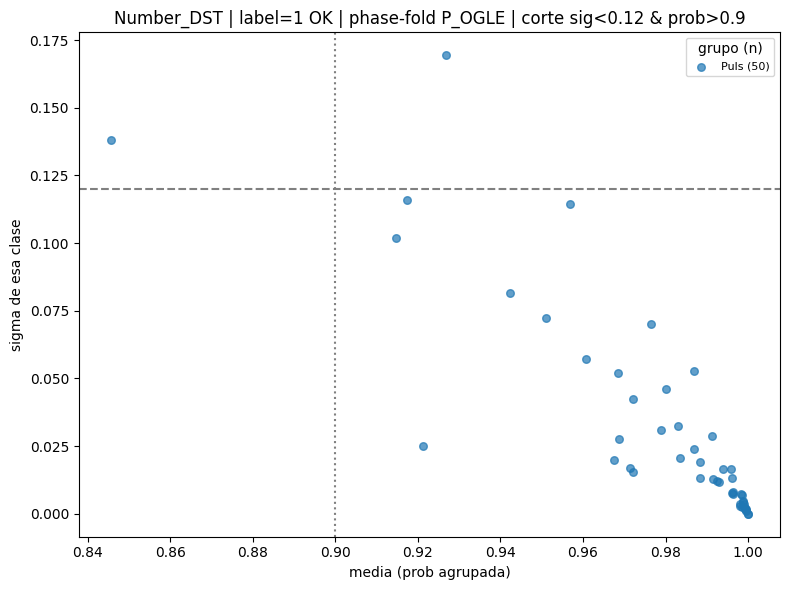

en el corte: 48/50 (TIC,sector)  | fuera (FN_seg): 2


In [142]:
# === label=1 OK: phase-fold con P_OGLE; clasificar con TODOS los pesos 1 vez =
import matplotlib.pyplot as plt
REF_MODEL = "Number_DST"; N_MC = 30
WEIGHTS_DIR = "/home/nicolas/nico/git/Paper_OGLE/Weights"

rev = pd.read_csv(REVIEW_CSV)
ok  = rev[rev["verdict"].astype(str) == "ok"][["TIC", "types", "per_ogle"]].copy()
ok["TIC"] = ok["TIC"].astype(int)
per_by_tic = dict(zip(ok["TIC"], ok["per_ogle"])); types_by_tic = dict(zip(ok["TIC"], ok["types"]))
print(f"estrellas OK: {len(ok)}")

lc_all_v = pd.read_parquet(LC_OGLE, columns=["Time", "flux", "TIC", "sector"])
Xs, recs = [], []
for (tic, sec), lc in lc_all_v.groupby(["TIC", "sector"]):
    if tic not in per_by_tic:
        continue
    P = float(per_by_tic[tic]); t = lc["Time"].to_numpy(); f = lc["flux"].to_numpy()
    m = np.isfinite(t) & np.isfinite(f); t, f = t[m], f[m]; a = amplitude_of(f)
    if len(t) < 20 or not np.isfinite(P) or P <= 0 or not np.isfinite(a):
        continue
    Xs.append(phase_fold_hist2d_log(t, f, P))
    recs.append({"TIC": int(tic), "sector": int(sec), "types": types_by_tic[tic], "per": P, "amplitud": a})
meta = pd.DataFrame(recs); Xok = np.array(Xs)[..., None].astype(np.float32); Pk = len(meta)
print(f"puntos (TIC x sector): {Pk} | TICs: {meta['TIC'].nunique()}")

# clasificar con los 7 pesos UNA sola vez -> meta_mc (lo comparten scatter y tabla)
per_row = meta["per"].to_numpy(); amp_row = meta["amplitud"].to_numpy()
meta_mc = {}
for name in MODELS:
    tf.keras.backend.clear_session(); m = make_model(); m.load_weights(f"{WEIGHTS_DIR}/{name}/cp.ckpt")
    probs_mc = np.stack([m(Xok, training=True).numpy() for _ in range(N_MC)])
    feat = pd.DataFrame(probs_mc.reshape(N_MC * Pk, 8), columns=CLASS_NAMES)
    feat["per"] = np.tile(per_row, N_MC); feat["amplitud"] = np.tile(amp_row, N_MC)
    hot = brf.predict_proba(feat[list(brf.feature_names_in_)]).reshape(N_MC, Pk, 8)
    meta_mc[name] = group_meansigma(hot)

meta["prob"], meta["sigma"], meta["clase"] = meta_mc[REF_MODEL]

fig, ax = plt.subplots(figsize=(8, 6))
for c in GROUP_NAMES:
    s = meta["clase"].to_numpy() == c
    if s.any():
        ax.scatter(meta["prob"][s], meta["sigma"][s], s=30, alpha=0.7, label=f"{c} ({int(s.sum())})")
ax.axhline(SIGMA_MAX, ls="--", c="gray"); ax.axvline(PROB_MIN, ls=":", c="gray")
ax.set_xlabel("media (prob agrupada)"); ax.set_ylabel("sigma de esa clase")
ax.set_title(f"{REF_MODEL} | label=1 OK | phase-fold P_OGLE | corte sig<{SIGMA_MAX} & prob>{PROB_MIN}")
ax.legend(fontsize=8, ncol=2, title="grupo (n)"); plt.tight_layout(); plt.show()

inb = (meta["prob"] > PROB_MIN) & (meta["sigma"] < SIGMA_MAX)
print(f"en el corte: {int(inb.sum())}/{Pk} (TIC,sector)  | fuera (FN_seg): {Pk - int(inb.sum())}")

### Tabla final — FPR (label=0) vs recall (label=1 OK) por (TIC,sector)

Todo a nivel (TIC,sector) para coincidir con el scatter: FN_seg = sectores OK fuera del corte. F1 balanceado por muestra. Por TIC único (combinando sectores) el FN baja a 0; esto es la vista honesta por observación.

In [143]:
# === Tabla final FPR vs recall por (TIC,sector) — usa meta_mc (consistente) =
TYPE2CLASS = {"Mira": "M", "lpv": "LPV", "rrlyr": "RR", "ELL": "ELL",
              "ecl": "E", "dsct": "DST", "cep": "CEP"}
exp_row = meta["types"].map(TYPE2CLASS).map(lambda c: CLASS2GROUP.get(c, c)).to_numpy()
Pk = len(meta)

rows = []
for name in MODELS:
    pr, sg, cl = meta_mc[name]                              # mismas probs que el scatter
    incut = (pr > PROB_MIN) & (sg < SIGMA_MAX)
    tp = int((incut & (cl == exp_row)).sum())               # (TIC,sector) en el corte y grupo correcto
    rows.append({"model": name, "TP": tp, "FN_seg": Pk - tp, "recall": round(tp / Pk, 3)})
tabla_acc = pd.DataFrame(rows)

# F1 balanceado por muestra (prior 50/50): precision = recall/(recall+FPR), por (TIC,sector).
final = tabla_fpr.merge(tabla_acc, on="model")
final["precision"] = final["recall"] / (final["recall"] + final["FPR"]).replace(0, np.nan)
den = (final["precision"] + final["recall"]).replace(0, np.nan)
final["F1"] = (2 * final["precision"] * final["recall"] / den).round(3)
final["precision"] = final["precision"].round(3)
final = final[["model", "FP_seg", "FN_seg", "FPR", "recall", "precision", "F1"]].sort_values(
    "F1", ascending=False).reset_index(drop=True)
print(f"=== Decision por (TIC,sector) @ sigma<{SIGMA_MAX} & prob>{PROB_MIN} | label=0 seg={n_seg0}, label=1 OK seg={Pk} ===")
print("  FP_seg=sector label0 marcado periodico | FN_seg=sector label1 OK fuera del corte | F1 balanceado por muestra")
print(final.to_string(index=False))

=== Decision por (TIC,sector) @ sigma<0.12 & prob>0.9 | label=0 seg=195, label=1 OK seg=50 ===
  FP_seg=sector label0 marcado periodico | FN_seg=sector label1 OK fuera del corte | F1 balanceado por muestra
                   model  FP_seg  FN_seg   FPR  recall  precision    F1
              Number_DST      23       2 0.118    0.96      0.891 0.924
                Number_M      26       6 0.133    0.88      0.869 0.874
batchBalanced_Number_DST      20      12 0.103    0.76      0.881 0.816
  batchBalanced_Number_M      28      12 0.144    0.76      0.841 0.798
              Number_ELL      20      16 0.103    0.68      0.868 0.763
batchBalanced_Number_ELL      31      15 0.159    0.70      0.815 0.753
              Number_CEP      35      15 0.179    0.70      0.796 0.745


### Scatter prob–σ de label=1 OK con Number_M

El mismo scatter de label=1 OK pero con el peso ganador del F1 balanceado (`Number_M`). Reusa
`Xok`/`meta` (celda del scatter de label=1); solo recalcula las probs con M.

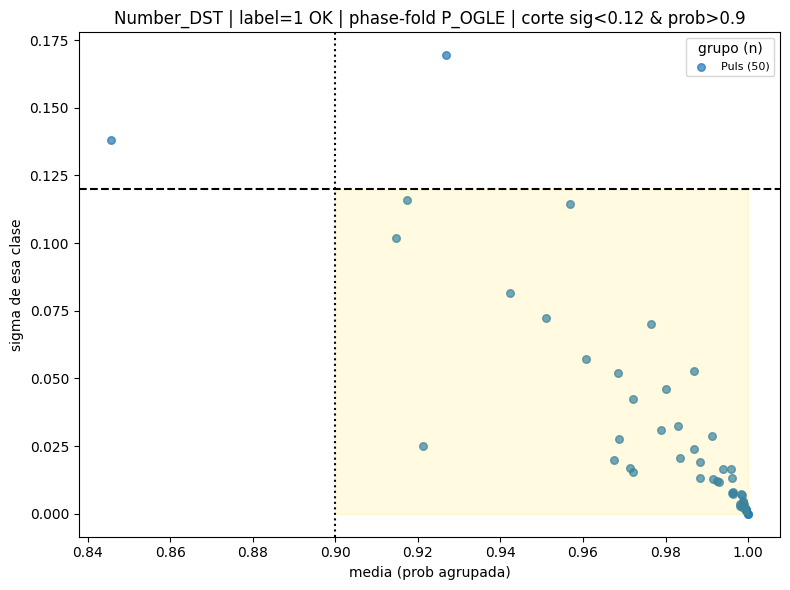

Number_DST label=1 OK en el corte: 48/50 (TIC,sector)  | fuera (FN_seg): 2


In [144]:
# === Scatter prob-sigma de label=1 OK con Number_M (desde meta_mc) ========
import matplotlib.pyplot as plt
MODEL_SHOW = "Number_DST"
pm, sm, cm = meta_mc[MODEL_SHOW]                            # mismas probs que la tabla
Pk = len(meta)

fig, ax = plt.subplots(figsize=(8, 6))
for c in GROUP_NAMES:
    s = cm == c
    if s.any():
        ax.scatter(pm[s], sm[s], s=30, alpha=0.7, label=f"{c} ({int(s.sum())})")
ax.axvline(PROB_MIN, ls=":", c="k"); ax.axhline(SIGMA_MAX, ls="--", c="k")
ax.fill_betweenx([0, SIGMA_MAX], PROB_MIN, 1.0, color="gold", alpha=0.12)
ax.set_xlabel("media (prob agrupada)"); ax.set_ylabel("sigma de esa clase")
ax.set_title(f"{MODEL_SHOW} | label=1 OK | phase-fold P_OGLE | corte sig<{SIGMA_MAX} & prob>{PROB_MIN}")
ax.legend(fontsize=8, ncol=2, title="grupo (n)"); plt.tight_layout(); plt.show()

inb = (pm > PROB_MIN) & (sm < SIGMA_MAX)
print(f"{MODEL_SHOW} label=1 OK en el corte: {int(inb.sum())}/{Pk} (TIC,sector)  | fuera (FN_seg): {Pk - int(inb.sum())}")

In [ ]:
# === PREGUNTA 1: el periodograma encuentra el periodo de OGLE? ============
# Solo periodograma (peaks_ogle = LS+ACF), SIN CNN ni cortes. Para cada
# (TIC,sector) de label=1 OK miramos si ALGUN peak detectado cae en el periodo
# reportado por OGLE (tolerancia relativa TOL).
import matplotlib.pyplot as plt
TOL = 0.05

# TICs label=1 OK + su P_OGLE
rev = pd.read_csv(REVIEW_CSV)
ok  = rev[rev["verdict"].astype(str) == "ok"][["TIC", "per_ogle"]].copy()
ok["TIC"] = ok["TIC"].astype(int)
per_ogle_by_tic = dict(zip(ok["TIC"], ok["per_ogle"].astype(float)))
tic1 = set(per_ogle_by_tic)

# universo de (TIC,sector) de esos TICs (desde las curvas), para contar los que
# NO tienen ningun peak detectado.
lc_keys = pd.read_parquet(LC_OGLE, columns=["TIC", "sector"]).drop_duplicates()
universe = lc_keys[lc_keys["TIC"].isin(tic1)].copy()
universe["TIC"] = universe["TIC"].astype(int); universe["sector"] = universe["sector"].astype(int)
n_seg = len(universe)

# peaks detectados de esos TICs
pk = peaks_ogle[peaks_ogle["TIC"].isin(tic1)].copy()
pk["TIC"] = pk["TIC"].astype(int); pk["sector"] = pk["sector"].astype(int)
pk["per_ogle"] = pk["TIC"].map(per_ogle_by_tic)
pk["reld"] = (pk["per"] / pk["per_ogle"] - 1.0).abs()         # cercania al periodo OGLE

# por (TIC,sector): #peaks y el peak mas cercano a P_OGLE
g = pk.groupby(["TIC", "sector"])
best = g.apply(lambda s: s.loc[s["reld"].idxmin()]).reset_index(drop=True)
best = best.rename(columns={"per": "per_best", "reld": "reld_best"})
res = universe.merge(best[["TIC", "sector", "source", "per_best", "per_ogle", "reld_best"]],
                     on=["TIC", "sector"], how="left")
res["n_peaks"] = res.set_index(["TIC", "sector"]).index.map(g.size()).fillna(0).astype(int).to_numpy()
res["tiene_peak"] = res["n_peaks"] > 0
res["found_ogle"] = res["reld_best"] <= TOL                    # algun peak ~ P_OGLE

n_peak  = int(res["tiene_peak"].sum())
n_found = int(res["found_ogle"].sum())
print(f"=== PREGUNTA 1: periodograma vs P_OGLE (label=1 OK) | tol={TOL:.0%} ===")
print(f"(TIC,sector) totales              : {n_seg}  (TICs: {res['TIC'].nunique()})")
print(f"  con >=1 peak detectado          : {n_peak}  ({n_peak/n_seg:.0%})")
print(f"  sin ningun peak                 : {n_seg - n_peak}")
print(f"  con un peak ~ P_OGLE (+-{TOL:.0%})    : {n_found}  ({n_found/n_seg:.0%} del total, {n_found/max(n_peak,1):.0%} de los que tienen peak)")
print(f"  TICs con al menos un sector OK  : {res.loc[res['found_ogle'],'TIC'].nunique()}/{len(tic1)}")

print("\nDetalle por (TIC,sector):")
cols = ["TIC", "sector", "n_peaks", "source", "per_best", "per_ogle", "reld_best", "found_ogle"]
print(res[cols].sort_values(["found_ogle", "reld_best"], ascending=[False, True]).to_string(index=False))

# scatter P_OGLE vs peak mas cercano detectado (solo (TIC,sector) con peak)
sub = res[res["tiene_peak"]]
fig, ax = plt.subplots(figsize=(6.5, 6))
lo = float(min(sub["per_ogle"].min(), sub["per_best"].min())) * 0.7
hi = float(max(sub["per_ogle"].max(), sub["per_best"].max())) * 1.4
ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.6, label="1:1")
for fac in (2.0, 0.5):
    ax.plot([lo, hi], [lo * fac, hi * fac], "gray", ls=":", lw=0.8, alpha=0.5)
mok = sub["found_ogle"].to_numpy()
ax.scatter(sub["per_ogle"][mok],  sub["per_best"][mok],  s=45, c="tab:green", zorder=3,
           label=f"P_OGLE encontrado ({int(mok.sum())})")
ax.scatter(sub["per_ogle"][~mok], sub["per_best"][~mok], s=45, c="tab:red", zorder=3,
           label=f"no ({int((~mok).sum())})")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("periodo OGLE [d]"); ax.set_ylabel("peak detectado mas cercano [d]")
ax.set_title(f"P1 | periodograma vs P_OGLE | label=1 OK (tol {TOL:.0%})")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()


## PREGUNTA 2 — por estrella: prob/sigma del BRF del peak OGLE vs los demas

Para cada `(TIC,sector)` de label=1 OK clasificamos **todos** sus peaks detectados
(`Number_DST`, MC-dropout) y comparamos prob/sigma del peak que cae en `P_OGLE`
(`is_ogle`) contra los otros. Objetivo: ver que regla separa el peak correcto
(mayor prob, menor sigma, o el corte prob>0.9 & sigma<0.12).

In [ ]:
# === P2: clasificar TODOS los peaks de cada (TIC,sector) y analizar 1x1 ====
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
BEST_MODEL = "Number_DST"; PROB_CUT, SIGMA_CUT, TOL = 0.90, 0.12, 0.05
NONPER = {"Rndm", "LPV"}                 # NO periodicas: se excluyen de la seleccion

rev = pd.read_csv(REVIEW_CSV)
ok  = rev[rev["verdict"].astype(str) == "ok"][["TIC", "per_ogle"]].copy()
ok["TIC"] = ok["TIC"].astype(int)
per_ogle_by_tic = dict(zip(ok["TIC"], ok["per_ogle"].astype(float)))
tic1 = set(per_ogle_by_tic)

mask = peaks_ogle["TIC"].isin(tic1).to_numpy() & np.isfinite(amp)
idx  = np.where(mask)[0]
pk1  = peaks_ogle.iloc[idx][["TIC", "sector", "source", "per", "power"]].reset_index(drop=True)
X1 = X[idx]; amp1 = amp[idx]; per1 = peaks_ogle["per"].to_numpy()[idx]; P1 = len(idx)

# clasificar todos los peaks una sola vez con Number_DST (MC-dropout)
tf.keras.backend.clear_session(); m = make_model(); m.load_weights(f"{WEIGHTS_DIR}/{BEST_MODEL}/cp.ckpt")
probs_mc = np.stack([m(X1, training=True).numpy() for _ in range(N_MC)])
feat = pd.DataFrame(probs_mc.reshape(N_MC * P1, 8), columns=CLASS_NAMES)
feat["per"] = np.tile(per1, N_MC); feat["amplitud"] = np.tile(amp1, N_MC)
hot = brf.predict_proba(feat[list(brf.feature_names_in_)]).reshape(N_MC, P1, 8)
pk1["prob"], pk1["sigma"], pk1["clase"] = group_meansigma(hot)
pk1["TIC"] = pk1["TIC"].astype(int); pk1["sector"] = pk1["sector"].astype(int)
pk1["per_ogle"] = pk1["TIC"].map(per_ogle_by_tic)
pk1["reld"] = (pk1["per"] / pk1["per_ogle"] - 1.0).abs()
pk1["is_ogle"] = pk1["reld"] <= TOL

keys = sorted(set(zip(pk1["TIC"].tolist(), pk1["sector"].tolist())))
print(f"(TIC,sector): {len(keys)} | peaks clasificados: {P1}")

def show_star(tic, sector):
    s = pk1[(pk1["TIC"] == tic) & (pk1["sector"] == sector)].sort_values("prob", ascending=False)
    P = per_ogle_by_tic[tic]; og = s[s["is_ogle"]]; notog = ~s["is_ogle"].to_numpy()
    # seleccion: solo clases periodicas (excluye Rndm/LPV), dentro del corte, mayor prob
    incut = s[(s["prob"] > PROB_CUT) & (s["sigma"] < SIGMA_CUT) & (~s["clase"].isin(NONPER))]
    print(f"=== TIC {tic} sector {sector} | P_OGLE={P:.5f} d | {len(s)} peaks ===")
    print(s[["source", "per", "power", "clase", "prob", "sigma", "reld", "is_ogle"]].to_string(index=False))
    if len(incut):
        t = incut.iloc[0]
        print(f"-> elegido (periodica, mayor prob en corte): per={t.per:.5f}  clase={t.clase}  is_ogle={bool(t.is_ogle)}  prob={t.prob:.3f}  sigma={t.sigma:.3f}")
    else:
        print("-> ningun peak periodico en el corte (prob>0.9 & sigma<0.12, clase no Rndm/LPV)")

    # en los plots: SOLO clases periodicas (excluye Rndm/LPV)
    sp = s[~s["clase"].isin(NONPER)].copy()
    # peak OGLE = UNO solo: el periodico mas cercano a P_OGLE (si cae dentro de tol)
    sp["is_ogle_peak"] = False
    cand = sp[sp["is_ogle"]]
    if len(cand):
        sp.loc[cand["reld"].idxmin(), "is_ogle_peak"] = True
    ogp = sp[sp["is_ogle_peak"]]; notogp = ~sp["is_ogle_peak"].to_numpy()

    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    ax[0].errorbar(sp["per"][notogp], sp["prob"][notogp], yerr=sp["sigma"][notogp], fmt="o",
                   c="tab:blue", alpha=0.6, label="otros peaks (periodicos)")
    if len(ogp):
        ax[0].errorbar(ogp["per"], ogp["prob"], yerr=ogp["sigma"], fmt="*", ms=18,
                       c="tab:green", label="peak ~ P_OGLE")
    ax[0].axvline(P, ls=":", c="green"); ax[0].axhline(PROB_CUT, ls="--", c="gray")
    ax[0].set_xscale("log"); ax[0].set_xlabel("periodo [d]"); ax[0].set_ylabel("BRF prob")
    ax[0].set_ylim(-0.02, 1.02); ax[0].legend(fontsize=8); ax[0].set_title("periodo vs prob (barra=sigma) | solo periodicas")

    ax[1].scatter(sp["prob"][notogp], sp["sigma"][notogp], c="tab:blue", alpha=0.6, label="otros")
    if len(ogp):
        ax[1].scatter(ogp["prob"], ogp["sigma"], marker="*", s=220, c="tab:green", label="P_OGLE")
    ax[1].axvline(PROB_CUT, ls=":", c="k"); ax[1].axhline(SIGMA_CUT, ls="--", c="k")
    ax[1].fill_betweenx([0, SIGMA_CUT], PROB_CUT, 1.0, color="gold", alpha=0.12)
    ax[1].set_xlabel("BRF prob"); ax[1].set_ylabel("sigma"); ax[1].legend(fontsize=8)
    ax[1].set_title("espacio del corte (zona dorada = OK)")
    fig.suptitle(f"TIC {tic} s{sector} | P_OGLE={P:.4f} d"); plt.tight_layout(); plt.show()

dd = widgets.Dropdown(options=[(f"TIC {t} s{se}", (t, se)) for t, se in keys], description="estrella")
out = widgets.Output()
def _on(_):
    out.clear_output(wait=True)
    with out:
        show_star(*dd.value)
dd.observe(_on, names="value")
display(dd, out)
with out:
    show_star(*dd.value)


In [ ]:
# === P2 final: scatter P_OGLE vs periodo seleccionado (corte + solo periodicas)
import matplotlib.pyplot as plt
# regla de seleccion: clase periodica (no Rndm/LPV) & prob>0.9 & sigma<0.12, mayor prob
sel = pk1[(~pk1["clase"].isin(NONPER)) & (pk1["prob"] > PROB_CUT) & (pk1["sigma"] < SIGMA_CUT)]
win = sel.sort_values("prob", ascending=False).groupby(["TIC", "sector"], as_index=False).first()
win["ratio"] = win["per"] / win["per_ogle"]
win["match"] = (win["ratio"] - 1.0).abs() <= TOL

n_seg = len(keys)                       # (TIC,sector) totales de label=1 OK
n_dec = len(win); n_rec = int(win["match"].sum())
print(f"=== Seleccion: periodica & prob>{PROB_CUT} & sigma<{SIGMA_CUT} | mayor prob ===")
print(f"(TIC,sector) totales            : {n_seg}")
print(f"(TIC,sector) con peak elegido   : {n_dec}  -> TICs: {win['TIC'].nunique()}")
print(f"periodo OGLE recuperado (+-{TOL:.0%})  : {n_rec}  ({n_rec/n_seg:.0%} del total, {n_rec/max(n_dec,1):.0%} de los decididos)")

fig, ax = plt.subplots(figsize=(6.5, 6))
lo = float(min(win["per_ogle"].min(), win["per"].min())) * 0.7
hi = float(max(win["per_ogle"].max(), win["per"].max())) * 1.4
ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.6, label="1:1")
for fac in (2.0, 0.5):
    ax.plot([lo, hi], [lo * fac, hi * fac], "gray", ls=":", lw=0.8, alpha=0.5)
mok = win["match"].to_numpy()
ax.scatter(win["per_ogle"][mok],  win["per"][mok],  s=50, c="tab:green", zorder=3,
           label=f"recuperado ({int(mok.sum())})")
ax.scatter(win["per_ogle"][~mok], win["per"][~mok], s=50, c="tab:red", zorder=3,
           label=f"no recuperado ({int((~mok).sum())})")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("periodo OGLE [d]"); ax.set_ylabel(f"periodo seleccionado ({BEST_MODEL}) [d]")
ax.set_title(f"P_OGLE vs seleccionado | periodica & prob>{PROB_CUT} & sigma<{SIGMA_CUT}")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

cols = ["TIC", "sector", "source", "clase", "prob", "sigma", "per", "per_ogle", "ratio", "match"]
print("\nDetalle:")
print(win[cols].sort_values(["match", "prob"], ascending=[False, False]).to_string(index=False))
